# Cross-Correlation Analysis

Cross-correlation is a mathematical operation that measures the similarity of two time series, $x(t)$ and $y(t)$, as a function of the time offset (or lag), $\tau$, between them.

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

In [21]:
# Data points (e.g., seconds)
N = 200
# The known time shift (the "misalignment") we want to find
TRUE_SHIFT = 15 
# Array of time indices
time = np.arange(N)

In [22]:
# A. Base Appliance Signature (A simple pulse)
# This simulates the "ON" event of an appliance at index 50
base_signal = np.zeros(N)
base_signal[50:60] = 1.0 # Power is 1.0 kW for 10 seconds

# B. Ground Truth Appliance Signal (P_app)
# This is the base signal, but delayed (shifted right) by TRUE_SHIFT
# We pad the beginning with zeros and truncate the end to simulate the delay.
P_app = np.concatenate([np.zeros(TRUE_SHIFT), 0.7*base_signal[:-TRUE_SHIFT]])

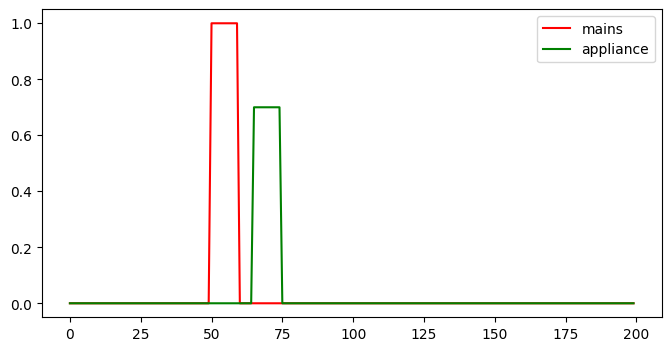

In [23]:
plt.figure(figsize=(8,4))
plt.plot(base_signal, color='red', label='mains')
plt.plot(P_app, color='green', label='appliance')
plt.legend()
plt.show()

In [24]:
# --- Calculate Cross-Correlation ---
# We use numpy's correlate function to calculate the CCF.
# The 'full' mode returns the correlation for all possible overlaps.
# We reverse P_agg because numpy's 'correlate' performs convolution,
# and for cross-correlation, one signal must be reversed.

correlation = signal.correlate(base_signal, P_app, mode='full')
lags = signal.correlation_lags(base_signal.size, P_app.size, mode='full')

In [25]:
# Find the index of the maximum correlation value
max_corr_index = np.argmax(correlation)
# The optimal lag is the lag value corresponding to that index
optimal_lag = lags[max_corr_index]

print(f"--- Alignment Results ---")
print(f"True Misalignment Shift: {TRUE_SHIFT} time steps")
print(f"Calculated Optimal Lag (τ_opt): {optimal_lag} time steps")

--- Alignment Results ---
True Misalignment Shift: 15 time steps
Calculated Optimal Lag (τ_opt): -15 time steps


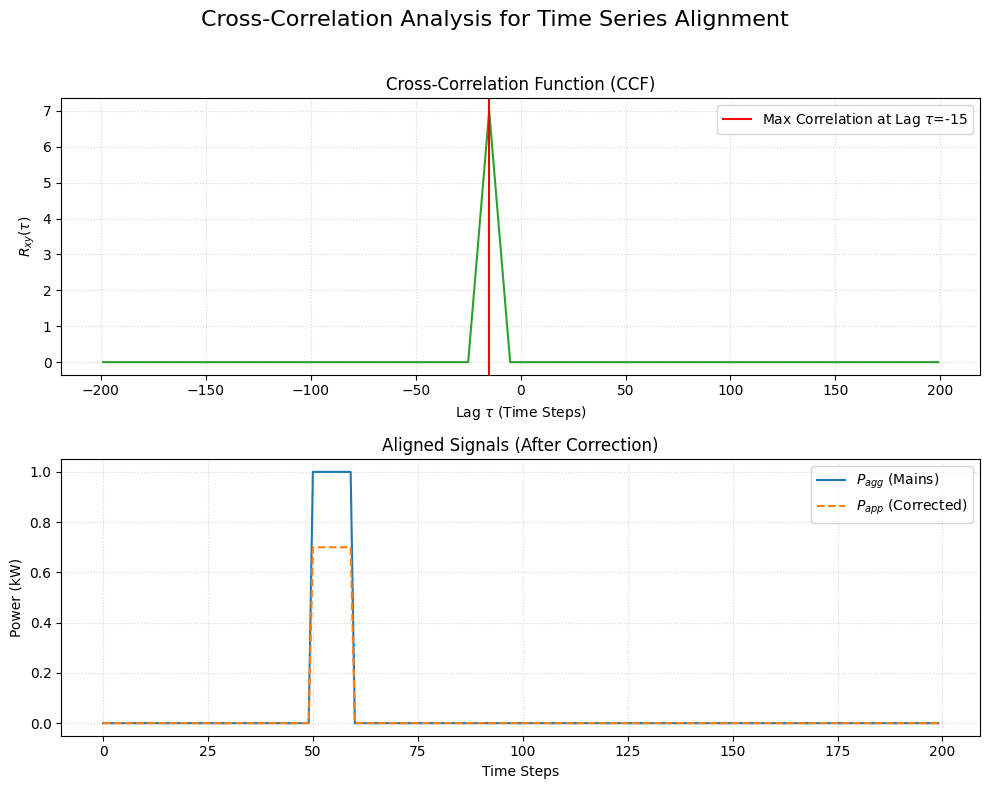

In [26]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=False)
plt.suptitle('Cross-Correlation Analysis for Time Series Alignment', fontsize=16)


# Plot 1: Cross-Correlation Function (CCF)
axes[0].plot(lags, correlation, color='tab:green')
axes[0].axvline(optimal_lag, color='red', linestyle='-', label=f'Max Correlation at Lag $\\tau$={optimal_lag}')
axes[0].set_title('Cross-Correlation Function (CCF)')
axes[0].set_xlabel('Lag $\\tau$ (Time Steps)')
axes[0].set_ylabel('$R_{xy}(\\tau)$')
axes[0].legend()
axes[0].grid(True, linestyle=':', alpha=0.5)

# Plot 2: Corrected Signals
# We shift the misaligned P_app back by the calculated optimal_lag
P_app_corrected = np.roll(P_app, optimal_lag)
# We ensure the rolling doesn't wrap-around unwanted data (important for real-world data)
# For this simple example, we just roll and plot:
axes[1].plot(time, base_signal, label='$P_{agg}$ (Mains)', color='tab:blue')
axes[1].plot(time, P_app_corrected, label='$P_{app}$ (Corrected)', color='tab:orange', linestyle='--')
axes[1].set_title('Aligned Signals (After Correction)')
axes[1].set_ylabel('Power (kW)')
axes[1].set_xlabel('Time Steps')
axes[1].legend()
axes[1].grid(True, linestyle=':', alpha=0.5)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()